EDA → visualizations → preprocessing → GaussianNB → prediction → accuracy → classification report → confusion matrix → probability visualization.

Wine Quality Classification with Gaussian Naive Bayes

In [3]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [11]:
df = pd.read_csv(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\supervised_machine_learning\Naive_Bayes\dataset\wine+quality (1)\winequality-red.csv",sep=";")

In [12]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
print(df.shape)

(1599, 12)


In [14]:
print(df.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [19]:
print(df.duplicated().sum())

240


In [20]:
df = df.drop_duplicates()
print(df.shape)

(1359, 12)


In [21]:
print(df["quality"].unique())

[5 6 7 4 8 3]


In [23]:
print(df["quality"].value_counts().sort_index())

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


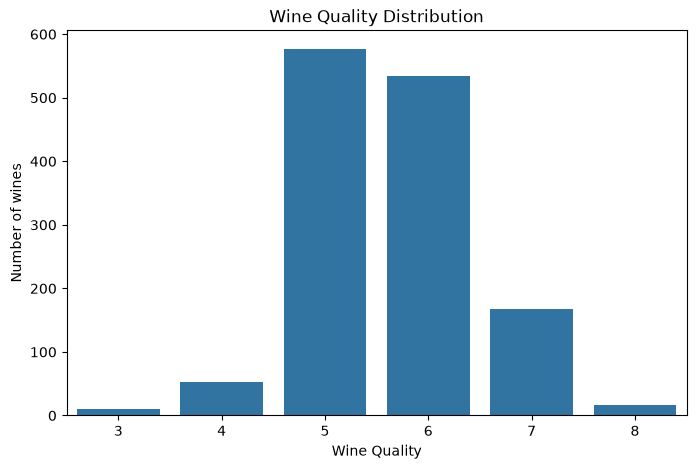

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="quality"
)

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of wines")

plt.show()

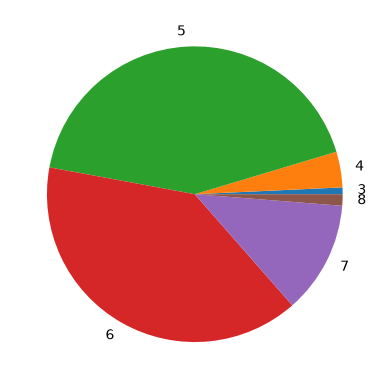

In [29]:
plt.pie(x=df["quality"].value_counts().sort_index(),labels=[3,4,5,6,7,8])

In [30]:
df["quality_label"] = df["quality"].apply(
    lambda x: 1 if x>=6 else 0
)

In [31]:
df[["quality","quality_label"]].head(10)

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,1
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0
10,5,0


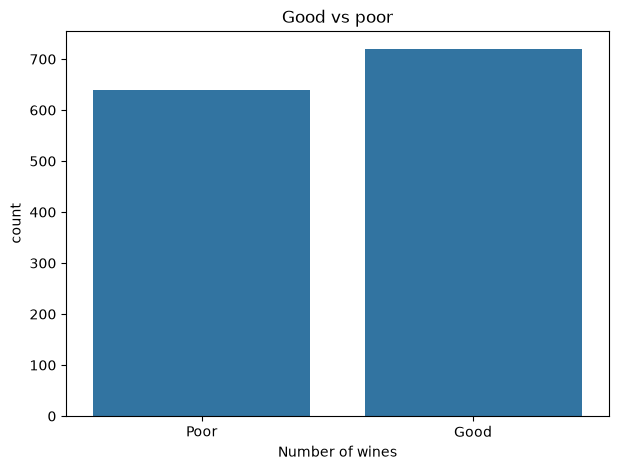

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="quality_label"
)

plt.xticks(
    [0,1],
    ["Poor","Good"]
)

plt.xlabel("Wine category")
plt.xlabel("Number of wines")
plt.title("Good vs poor")

plt.show()

In [33]:
correlation = df.drop(
    columns=["quality_label"]
).corr()

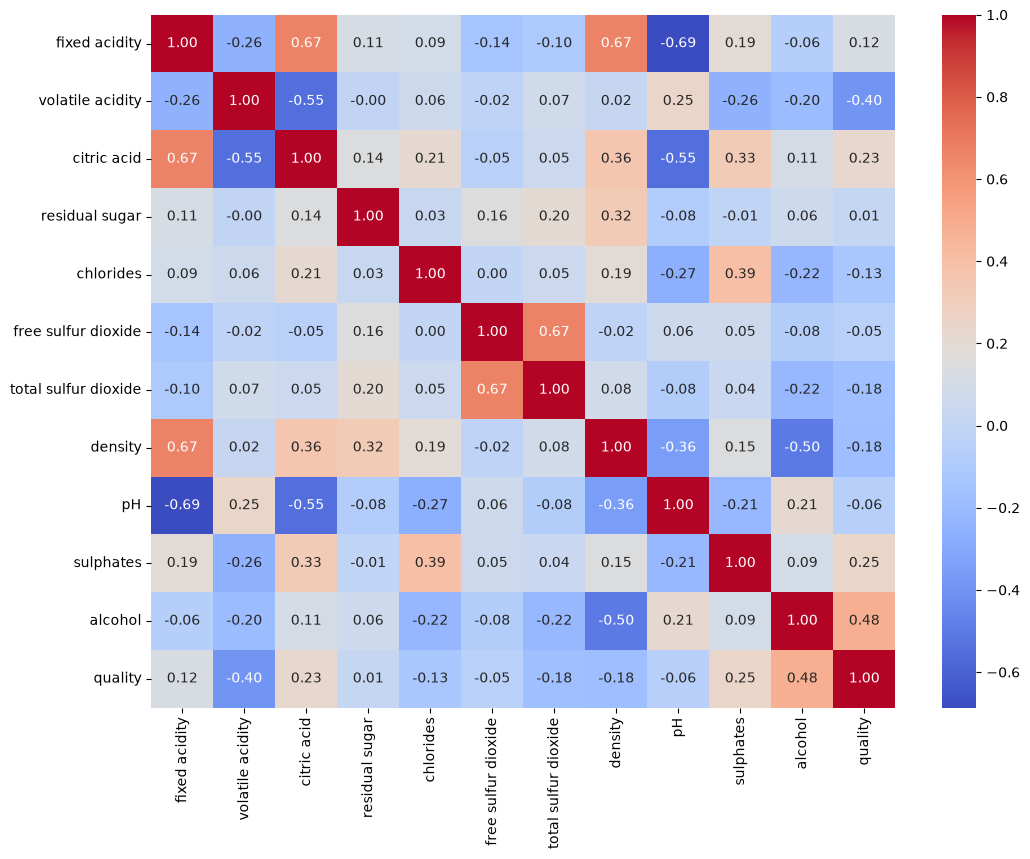

In [34]:
plt.figure(figsize=(12,9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.show()

In [35]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [36]:
quality_corr = df.corr(numeric_only=True)["quality"].sort_values(
    ascending=False
)

print(quality_corr)

quality                 1.000000
quality_label           0.844955
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


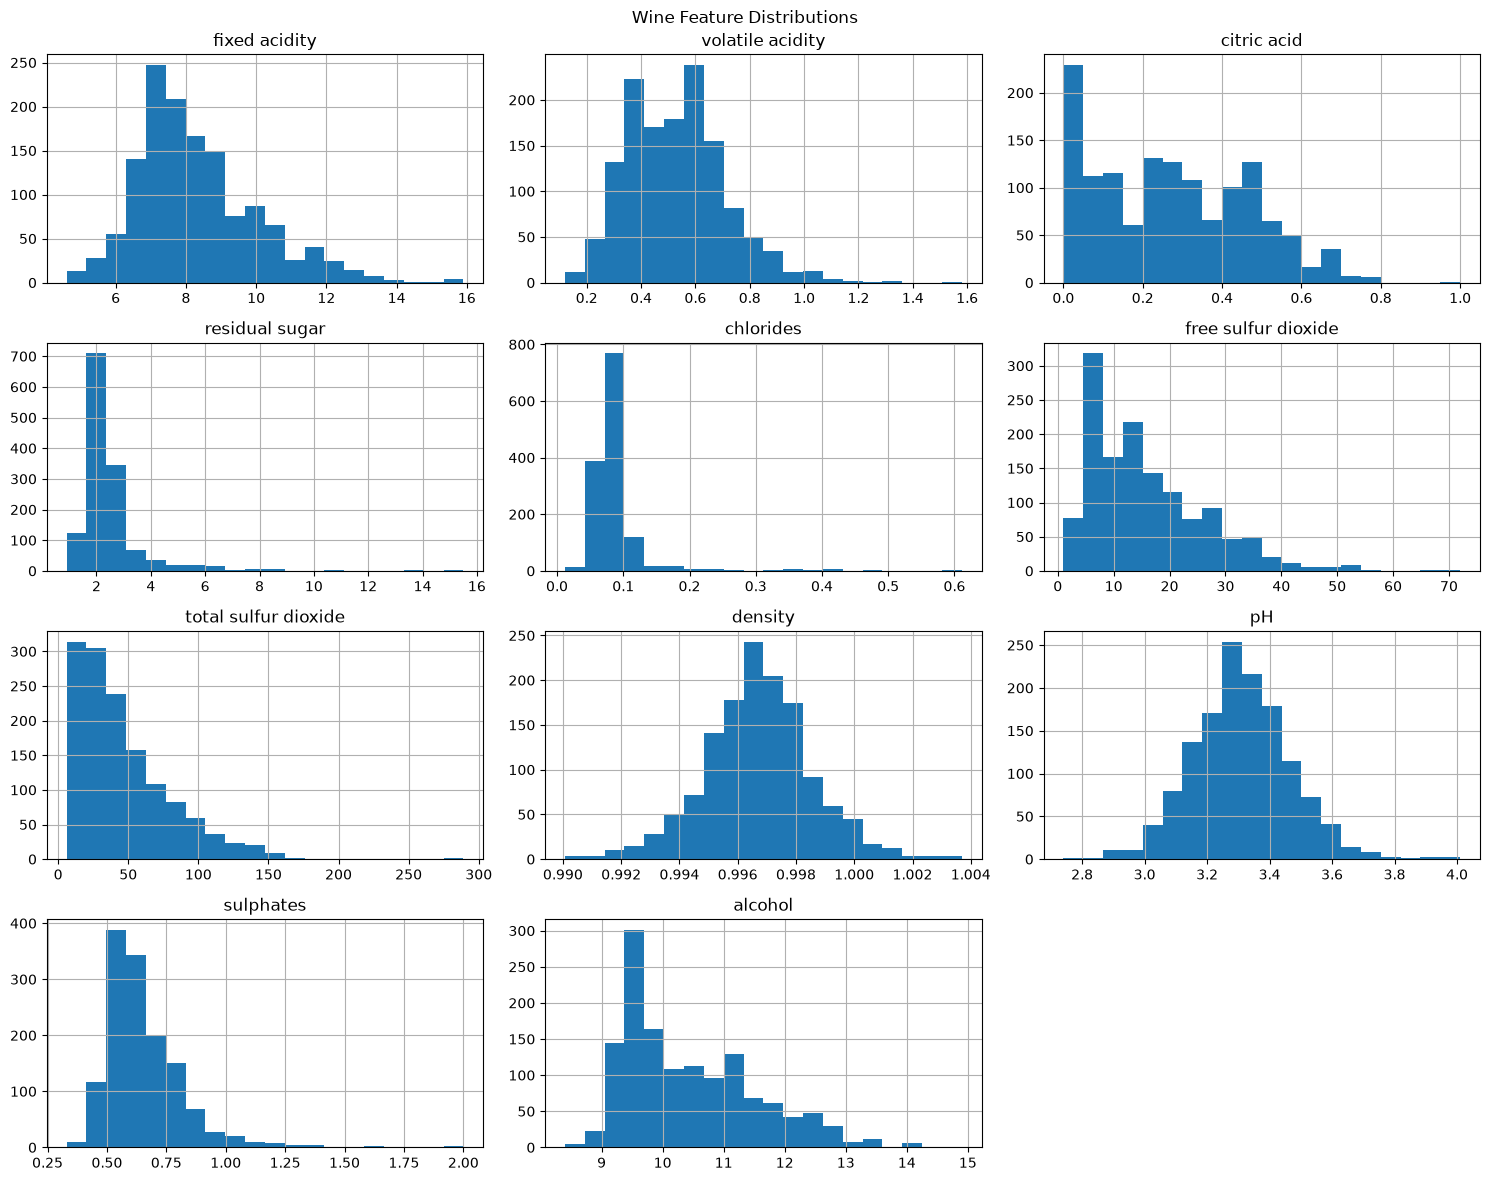

In [37]:
df.drop(
    columns=["quality", "quality_label"]
).hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Wine Feature Distributions")

plt.tight_layout()

plt.show()

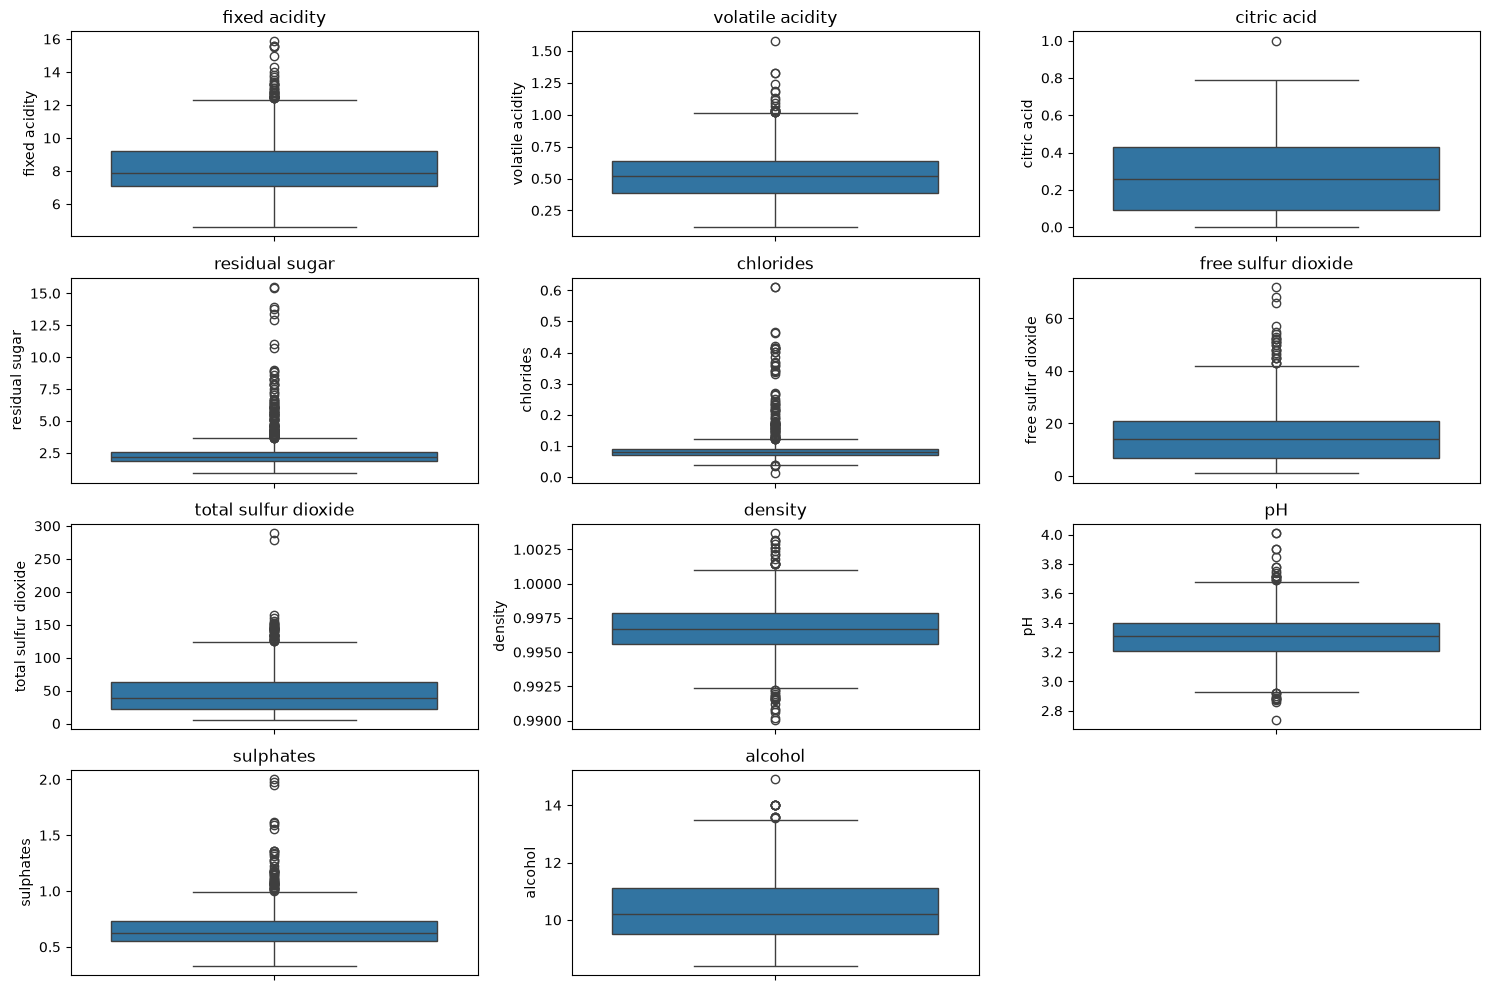

In [38]:
plt.figure(figsize=(15, 10))

features = df.drop(
    columns=["quality", "quality_label"]
).columns

for i, feature in enumerate(features, 1):

    plt.subplot(4, 3, i)

    sns.boxplot(
        y=df[feature]
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

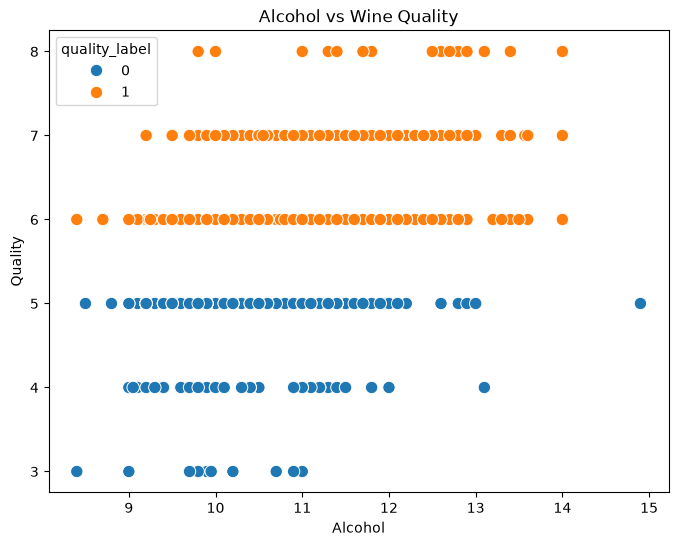

In [39]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="alcohol",
    y="quality",
    hue="quality_label",
    s=80
)

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.show()

In [40]:
X = df.drop(
    columns=["quality", "quality_label"]
)

y = df["quality_label"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
model = GaussianNB()

In [43]:
model.fit(
    X_train,
    y_train
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[512.,575.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.47,0.53]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.154e-06
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[ 8.1 , 0.59, 0.24,..., 3.31, 0.62, 9.92], [ 8.49, 0.48, 0.3 ,..., 3.31, 0.69,10.91]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[2.4 ,0.03,0.03,...,0.02,0.03,0.6 ], [3.56,0.03,0.04,...,0.02,0.03,1.23]]"


In [44]:
y_pred = model.predict(X_test)

In [45]:
print(y_pred[:20])

[0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1]


In [46]:
print(
    "Accuracy : ",
    accuracy_score(y_test, y_pred)
)

Accuracy :  0.7242647058823529


In [47]:
accuracy = accuracy_score(y_test, y_pred)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 72.43%


In [48]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Poor", "Good"]
    )
)

              precision    recall  f1-score   support

        Poor       0.69      0.76      0.72       128
        Good       0.76      0.69      0.73       144

    accuracy                           0.72       272
   macro avg       0.73      0.73      0.72       272
weighted avg       0.73      0.72      0.72       272



In [49]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 97  31]
 [ 44 100]]


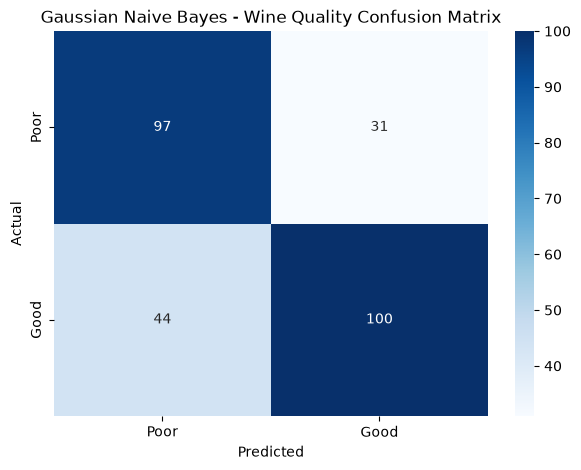

In [50]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Poor", "Good"],
    yticklabels=["Poor", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Gaussian Naive Bayes - Wine Quality Confusion Matrix"
)

plt.show()

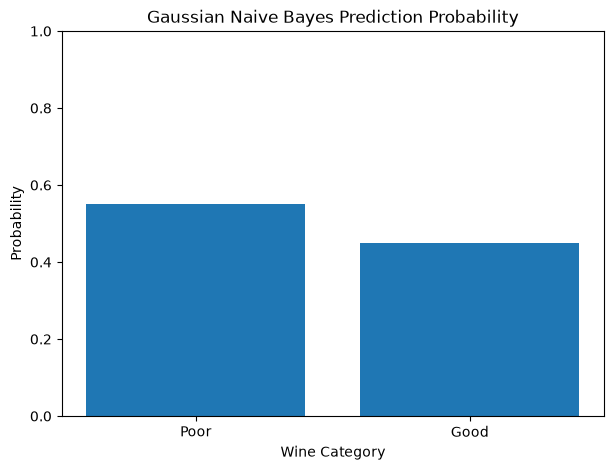

In [51]:
sample_index = 0

probability = model.predict_proba(
    X_test.iloc[[sample_index]]
)[0]

plt.figure(figsize=(7, 5))

plt.bar(
    ["Poor", "Good"],
    probability
)

plt.ylim(0, 1)

plt.xlabel("Wine Category")
plt.ylabel("Probability")

plt.title(
    "Gaussian Naive Bayes Prediction Probability"
)

plt.show()

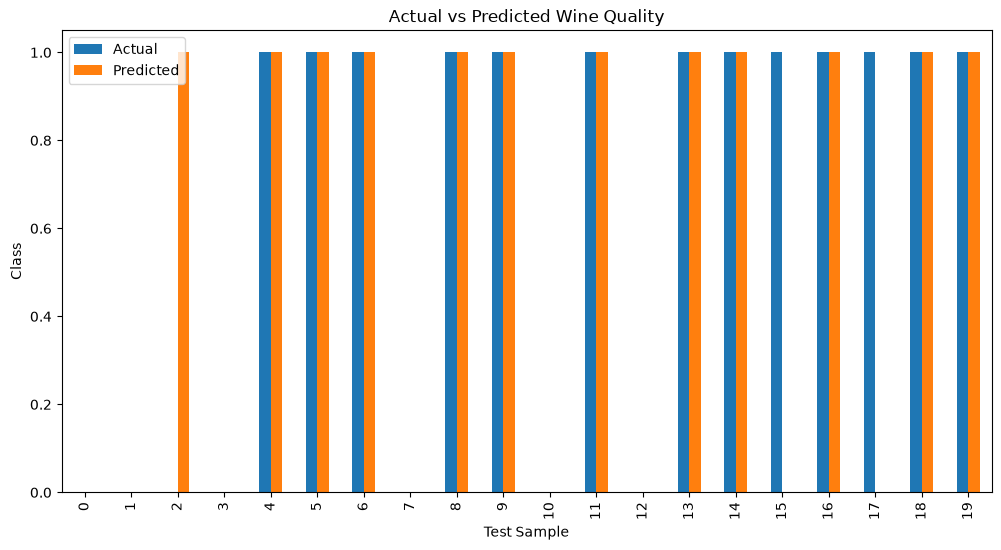

In [52]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Actual vs Predicted Wine Quality")
plt.xlabel("Test Sample")
plt.ylabel("Class")

plt.legend()

plt.show()

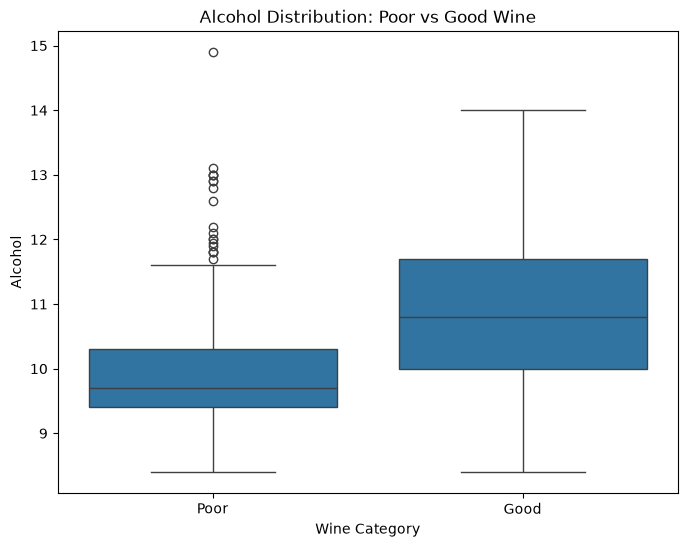

In [53]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="quality_label",
    y="alcohol"
)

plt.xticks(
    [0, 1],
    ["Poor", "Good"]
)

plt.title(
    "Alcohol Distribution: Poor vs Good Wine"
)

plt.xlabel("Wine Category")
plt.ylabel("Alcohol")

plt.show()